# Initial Tests
- ~~Access astroquerry databases~~
- Open real image from HST
- Open spectrum


In [2]:
from astropy.io import fits
from astroquery.esa.hubble import ESAHubble

In [3]:
#Gathering references to hubble object and querry table for M31
hubble = ESAHubble()
table = hubble.query_target(name="m31", filename="m31_query.xml.gz")

In [4]:
table.show_in_browser(100)

In [ ]:
#Ahh, I see the issue now. I need to make sure the FOV is high enough, so I should be sorting based on FOV.
table.sort('fov_size', reverse=True)
table.show_in_browser(100, jsviewer=True)

hubble

In [ ]:
#Ok, from the table it seems like the first entry might be promising. Let's open it using matplotlib.
%matplotlib inline
import matplotlib.pyplot as plt

id = table[100]['observation_id']
image = hubble.download_fits_files(observation_id=id)
with fits.open(f"{id}_drc.fits.gz") as hdul:
    image = hdul[0].data
fig = plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.colorbar()

Filename: hst_9087_08_acs_wfc_f435w_j6d508ot_flc.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     298   ()      
  1  SCI           1 ImageHDU       269   (4096, 2048)   float32   
  2  ERR           1 ImageHDU        53   (4096, 2048)   float32   
  3  DQ            1 ImageHDU        45   (4096, 2048)   int16   
  4  SCI           2 ImageHDU       267   (4096, 2048)   float32   
  5  ERR           2 ImageHDU        53   (4096, 2048)   float32   
  6  DQ            2 ImageHDU        45   (4096, 2048)   int16   
  7  D2IMARR       1 ImageHDU        16   (64, 32)   float32   
  8  D2IMARR       2 ImageHDU        16   (64, 32)   float32   
  9  D2IMARR       3 ImageHDU        16   (64, 32)   float32   
 10  D2IMARR       4 ImageHDU        16   (64, 32)   float32   
 11  WCSDVARR      1 ImageHDU        16   (64, 32)   float32   
 12  WCSDVARR      2 ImageHDU        16   (64, 32)   float32   
 13  WCSDVARR      3 ImageHDU        16   

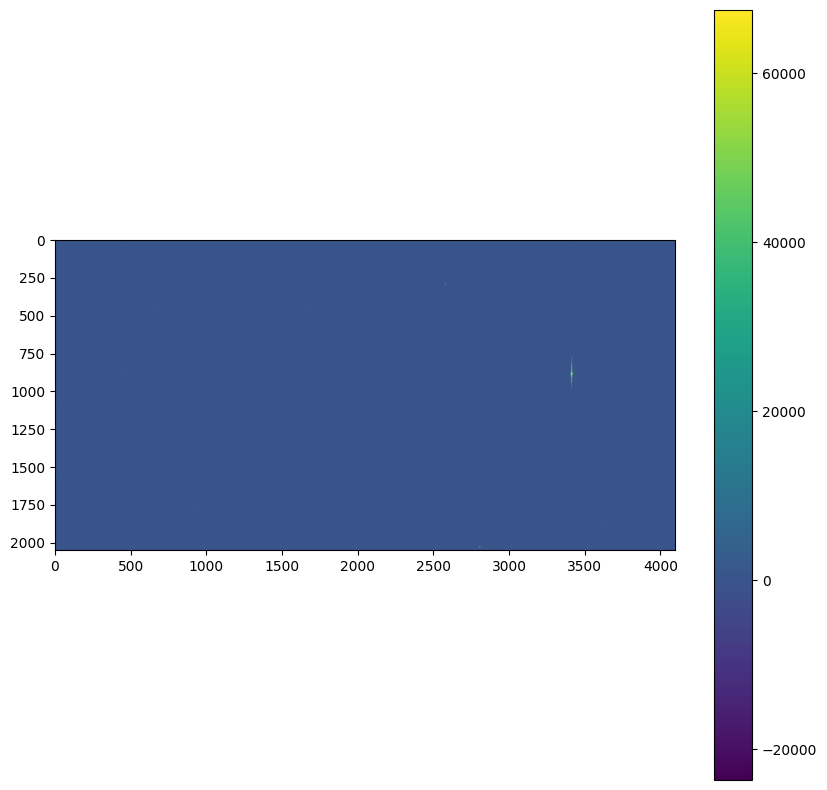

In [15]:
id = table[100]['observation_id']

with fits.open(f"{id}_flc.fits.gz") as hdul:
    hdul.info()
    image = hdul[1].data
fig = plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.colorbar()

